# 01. PyTorch 텐서 연산

**모듈**: M2 - 딥러닝 기초
**날짜**: 2026-03-09

딥러닝의 기본 데이터 단위인 **텐서(Tensor)**를 다룹니다.

```
NumPy 배열  →  PyTorch 텐서  →  신경망 입출력
(CPU 계산)     (GPU 가속)       (자동 미분)
```

**핵심**: 텐서 = NumPy 배열 + GPU + 자동 미분

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# macOS 한글 폰트
mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False

print(f'PyTorch: {torch.__version__}')
print(f'MPS 사용 가능: {torch.backends.mps.is_available()}')
print(f'기본 장치: {"mps" if torch.backends.mps.is_available() else "cpu"}')

PyTorch: 2.10.0
MPS 사용 가능: True
기본 장치: mps


## 1. 텐서 생성하기

텐서를 만드는 4가지 방법:
- 직접 값 지정
- NumPy 배열에서 변환
- 랜덤 생성
- 특수 텐서 (zeros, ones, eye)

In [2]:
# 1. 직접 값 지정
t1 = torch.tensor([1, 2, 3, 4, 5])
print(f'직접 생성: {t1}')
print(f'  shape: {t1.shape}, dtype: {t1.dtype}')

# 2. NumPy → 텐서 (M1에서 만든 센서 데이터를 텐서로!)
np_array = np.array([0.2, 0.5, 0.9, 1.0, 1.0, 1.0, 0.8, 0.4])  # 거리센서
t2 = torch.from_numpy(np_array)
print(f'\nNumPy → 텐서: {t2}')
print(f'  shape: {t2.shape}, dtype: {t2.dtype}')

# 3. 랜덤 생성
t3 = torch.randn(3, 4)  # 정규분포 (평균0, 표준편차1)
print(f'\n랜덤 텐서 (3x4):')
print(t3)

# 4. 특수 텐서
t_zeros = torch.zeros(2, 3)
t_ones = torch.ones(2, 3)
t_eye = torch.eye(3)  # 단위행렬
print(f'\n영행렬:\n{t_zeros}')
print(f'\n단위행렬:\n{t_eye}')

직접 생성: tensor([1, 2, 3, 4, 5])
  shape: torch.Size([5]), dtype: torch.int64

NumPy → 텐서: tensor([0.2000, 0.5000, 0.9000, 1.0000, 1.0000, 1.0000, 0.8000, 0.4000],
       dtype=torch.float64)
  shape: torch.Size([8]), dtype: torch.float64

랜덤 텐서 (3x4):
tensor([[ 0.4320, -0.9219,  0.2665, -1.5567],
        [ 0.9809, -1.4727,  2.1594,  1.3169],
        [-1.7566,  0.6454,  1.8615, -0.1932]])

영행렬:
tensor([[0., 0., 0.],
        [0., 0., 0.]])

단위행렬:
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])


## 2. 센서 데이터를 텐서로 변환

M1에서 만든 센서 데이터의 shape을 텐서로 바꿔보면:

| 센서 | NumPy shape | 텐서 shape | 의미 |
|------|------------|------------|------|
| 카메라 | (64,64,3) | (3,64,64) | PyTorch는 채널 먼저! |
| 거리 | (8,) | (8,) | 그대로 |
| 오디오 | (2,100) | (2,100) | 그대로 |
| IMU | (6,) | (6,) | 그대로 |

In [3]:
# M1 센서 데이터를 텐서로 변환

# 카메라: (H, W, C) → (C, H, W) 변환 필요 (PyTorch 규칙)
camera_np = np.random.randint(0, 256, (64, 64, 3), dtype=np.uint8)
camera_tensor = torch.from_numpy(camera_np).permute(2, 0, 1).float() / 255.0
print(f'카메라: NumPy {camera_np.shape} → 텐서 {camera_tensor.shape}')
print(f'  값 범위: {camera_tensor.min():.2f} ~ {camera_tensor.max():.2f} (0~1 정규화)')

# 거리센서
distance_np = np.array([0.2, 0.5, 0.9, 1.0, 1.0, 1.0, 0.8, 0.4])
distance_tensor = torch.from_numpy(distance_np).float()
print(f'\n거리:   NumPy {distance_np.shape} → 텐서 {distance_tensor.shape}')

# 오디오
audio_np = np.random.randn(2, 100).astype(np.float32)
audio_tensor = torch.from_numpy(audio_np)
print(f'오디오: NumPy {audio_np.shape} → 텐서 {audio_tensor.shape}')

# IMU
imu_np = np.array([0.5, 0.1, 0.0, 0.05, 0.2, 15.0], dtype=np.float32)
imu_tensor = torch.from_numpy(imu_np)
print(f'IMU:   NumPy {imu_np.shape} → 텐서 {imu_tensor.shape}')

print(f'\n핵심: PyTorch 이미지는 (C, H, W) 순서! NumPy는 (H, W, C)')

카메라: NumPy (64, 64, 3) → 텐서 torch.Size([3, 64, 64])
  값 범위: 0.00 ~ 1.00 (0~1 정규화)

거리:   NumPy (8,) → 텐서 torch.Size([8])
오디오: NumPy (2, 100) → 텐서 torch.Size([2, 100])
IMU:   NumPy (6,) → 텐서 torch.Size([6])

핵심: PyTorch 이미지는 (C, H, W) 순서! NumPy는 (H, W, C)


## 3. 텐서 연산

텐서로 할 수 있는 핵심 연산들. 신경망의 모든 계산이 이것들의 조합입니다.

In [4]:
# 기본 연산
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print('=== 기본 연산 ===')
print(f'a + b = {a + b}')           # 요소별 덧셈
print(f'a * b = {a * b}')           # 요소별 곱셈
print(f'a @ b = {a @ b}')           # 내적 (dot product)
print(f'a.sum() = {a.sum()}')       # 합계
print(f'a.mean() = {a.mean()}')     # 평균

# 행렬 연산 (신경망의 핵심!)
print('\n=== 행렬 연산 ===')
W = torch.randn(4, 3)   # 가중치 행렬 (출력4 x 입력3)
x = torch.randn(3)      # 입력 벡터 (3차원)
y = W @ x                # 행렬-벡터 곱 = 선형 변환
print(f'W shape: {W.shape}')
print(f'x shape: {x.shape}')
print(f'y = W @ x → shape: {y.shape}')
print(f'→ 3차원 입력이 4차원 출력으로 변환됨!')

# reshape (차원 변경)
print('\n=== Reshape ===')
img = torch.randn(3, 64, 64)  # 카메라 이미지
flat = img.reshape(-1)         # 1D로 펴기
print(f'이미지: {img.shape} → flatten: {flat.shape}')
print(f'→ {3*64*64:,}개 숫자가 신경망에 입력됨')

=== 기본 연산 ===
a + b = tensor([5., 7., 9.])
a * b = tensor([ 4., 10., 18.])
a @ b = 32.0
a.sum() = 6.0
a.mean() = 2.0

=== 행렬 연산 ===
W shape: torch.Size([4, 3])
x shape: torch.Size([3])
y = W @ x → shape: torch.Size([4])
→ 3차원 입력이 4차원 출력으로 변환됨!

=== Reshape ===
이미지: torch.Size([3, 64, 64]) → flatten: torch.Size([12288])
→ 12,288개 숫자가 신경망에 입력됨


## 4. 신경망의 핵심: 선형 변환 + 활성화 함수

신경망 한 층이 하는 일:
```
y = activation(W @ x + b)
```
- `W @ x + b`: 선형 변환 (행렬곱 + 편향)
- `activation`: 비선형성 추가 (ReLU가 가장 많이 사용)

=== 수동 신경망 (2층) ===
입력 (거리센서):  torch.Size([8]) → [0.20000000298023224, 0.5, 0.8999999761581421, 1.0, 1.0, 1.0, 0.800000011920929, 0.4000000059604645]
은닉층 (ReLU후): torch.Size([16])
출력:            torch.Size([4]) → [0.018225684762001038, 0.03766274079680443, -0.02689596265554428, -0.015861686319112778]

이 출력이 나중에 행동(앞/뒤/좌/우)의 점수가 됩니다!


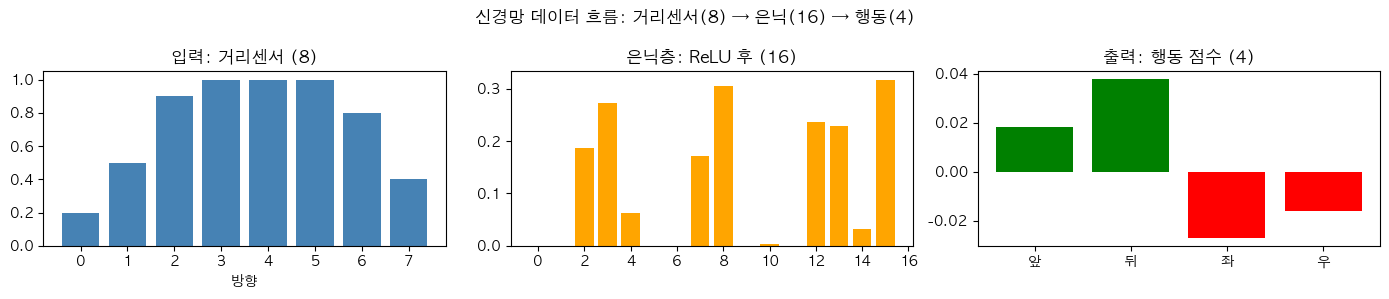

In [5]:
# 신경망 한 층을 직접 구현해보기
torch.manual_seed(42)

# 입력: 거리센서 8개 값
x = distance_tensor  # (8,)

# 층 1: 8차원 → 16차원
W1 = torch.randn(16, 8) * 0.1   # 가중치
b1 = torch.zeros(16)             # 편향
h1 = torch.relu(W1 @ x + b1)    # 선형변환 + ReLU

# 층 2: 16차원 → 4차원 (출력)
W2 = torch.randn(4, 16) * 0.1
b2 = torch.zeros(4)
output = W2 @ h1 + b2

print('=== 수동 신경망 (2층) ===')
print(f'입력 (거리센서):  {x.shape} → {x.tolist()}')
print(f'은닉층 (ReLU후): {h1.shape}')
print(f'출력:            {output.shape} → {output.tolist()}')
print()
print('이 출력이 나중에 행동(앞/뒤/좌/우)의 점수가 됩니다!')

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

axes[0].bar(range(8), x.numpy(), color='steelblue')
axes[0].set_title('입력: 거리센서 (8)')
axes[0].set_xlabel('방향')

axes[1].bar(range(16), h1.detach().numpy(), color='orange')
axes[1].set_title('은닉층: ReLU 후 (16)')

actions = ['앞', '뒤', '좌', '우']
colors = ['green' if v > 0 else 'red' for v in output.detach().numpy()]
axes[2].bar(actions, output.detach().numpy(), color=colors)
axes[2].set_title('출력: 행동 점수 (4)')

plt.suptitle('신경망 데이터 흐름: 거리센서(8) → 은닉(16) → 행동(4)', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. GPU 가속 (MPS)

Apple Silicon Mac에서는 **MPS (Metal Performance Shaders)**로 GPU 연산 가능.
큰 텐서일수록 GPU가 빠릅니다.

In [6]:
import time

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'사용 장치: {device}')

# CPU vs GPU 속도 비교 (큰 행렬곱)
size = 2000

# CPU
a_cpu = torch.randn(size, size)
b_cpu = torch.randn(size, size)
start = time.time()
for _ in range(10):
    c_cpu = a_cpu @ b_cpu
cpu_time = (time.time() - start) / 10

# GPU (MPS)
if device.type == 'mps':
    a_gpu = a_cpu.to(device)
    b_gpu = b_cpu.to(device)
    # 워밍업
    _ = a_gpu @ b_gpu
    torch.mps.synchronize()
    
    start = time.time()
    for _ in range(10):
        c_gpu = a_gpu @ b_gpu
    torch.mps.synchronize()
    gpu_time = (time.time() - start) / 10
    
    print(f'\n{size}x{size} 행렬곱 속도:')
    print(f'  CPU: {cpu_time*1000:.1f}ms')
    print(f'  MPS: {gpu_time*1000:.1f}ms')
    print(f'  가속: {cpu_time/gpu_time:.1f}x 빠름!')
else:
    print('MPS 미지원 → CPU만 사용')
    print(f'CPU: {cpu_time*1000:.1f}ms')

# 텐서를 GPU로 보내기
print(f'\n텐서 이동:')
t = torch.randn(3, 4)
print(f'  CPU: {t.device}')
t_gpu = t.to(device)
print(f'  GPU: {t_gpu.device}')

사용 장치: mps



2000x2000 행렬곱 속도:
  CPU: 10.1ms
  MPS: 2.7ms
  가속: 3.8x 빠름!

텐서 이동:
  CPU: cpu
  GPU: mps:0


## 6. 자동 미분 (Autograd) - 학습의 핵심

신경망 학습 = **기울기(gradient)**를 계산해서 가중치를 조정하는 것.

PyTorch가 자동으로 기울기를 계산해줍니다:
1. `requires_grad=True`로 텐서 생성
2. 연산 수행 (순전파)
3. `.backward()` 호출 → 기울기 자동 계산 (역전파)
4. `.grad`에서 기울기 확인

In [7]:
# 예제 1: 간단한 함수의 기울기
# y = x^2 → dy/dx = 2x

x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()  # 역전파: 기울기 계산

print('=== 자동 미분 예제 1 ===')
print(f'x = {x.item()}')
print(f'y = x² = {y.item()}')
print(f'dy/dx = 2x = {x.grad.item()}  (자동 계산!)')
print(f'검증: 2 × {x.item()} = {2 * x.item()}')

=== 자동 미분 예제 1 ===
x = 3.0
y = x² = 9.0
dy/dx = 2x = 6.0  (자동 계산!)
검증: 2 × 3.0 = 6.0


In [8]:
# 예제 2: 신경망 학습 시뮬레이션
# 목표: 거리센서 값 → "위험도" 예측

torch.manual_seed(42)

# 학습 데이터: 거리가 가까우면 위험도 높음
distances = torch.tensor([0.1, 0.3, 0.5, 0.7, 0.9], requires_grad=False)
dangers = torch.tensor([0.9, 0.7, 0.5, 0.3, 0.1])   # 정답

# 모델: y = w * x + b (단순 선형)
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

learning_rate = 0.1
losses = []

print('=== 학습 과정 ===')
for epoch in range(50):
    # 순전파
    predictions = w * distances + b
    
    # 손실 계산 (MSE: 예측과 정답의 차이 제곱 평균)
    loss = ((predictions - dangers) ** 2).mean()
    losses.append(loss.item())
    
    # 역전파 (기울기 계산)
    loss.backward()
    
    # 가중치 업데이트 (기울기 반대 방향으로)
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
    
    # 기울기 초기화 (매 반복 필수!)
    w.grad.zero_()
    b.grad.zero_()
    
    if epoch % 10 == 0:
        print(f'  Epoch {epoch:2d}: loss={loss.item():.4f}, w={w.item():.3f}, b={b.item():.3f}')

print(f'\n학습 결과: y = {w.item():.3f} * x + {b.item():.3f}')
print(f'의미: 거리가 {1:.1f}일 때 위험도 = {(w.item() * 1 + b.item()):.2f}')
print(f'      거리가 {0:.1f}일 때 위험도 = {(w.item() * 0 + b.item()):.2f}')

=== 학습 과정 ===
  Epoch  0: loss=0.3300, w=0.034, b=0.100
  Epoch 10: loss=0.0903, w=0.030, b=0.431
  Epoch 20: loss=0.0695, w=-0.086, b=0.511
  Epoch 30: loss=0.0539, w=-0.195, b=0.570
  Epoch 40: loss=0.0418, w=-0.291, b=0.622

학습 결과: y = -0.368 * x + 0.663
의미: 거리가 1.0일 때 위험도 = 0.29
      거리가 0.0일 때 위험도 = 0.66


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


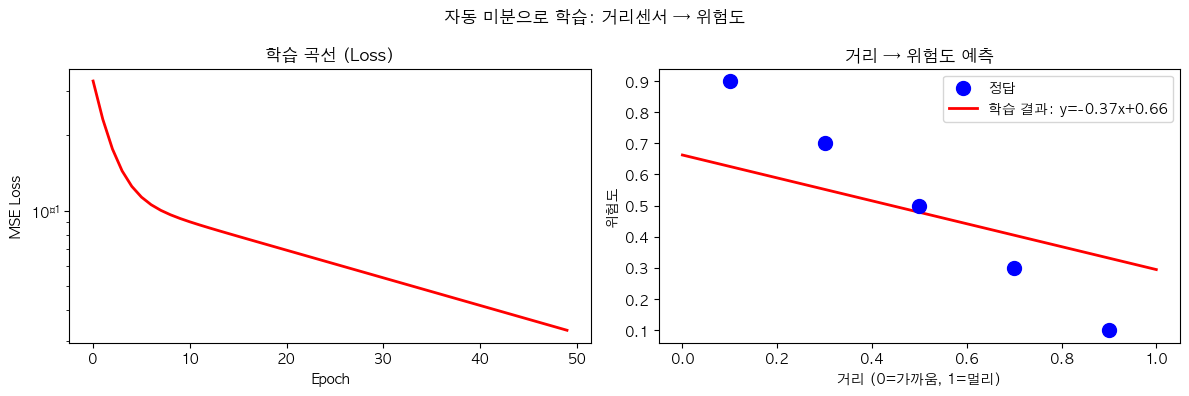

핵심: backward()가 기울기를 계산 → 가중치를 조금씩 조정 → loss가 줄어듦!


In [9]:
# 학습 과정 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 손실 곡선
ax1.plot(losses, color='red', linewidth=2)
ax1.set_title('학습 곡선 (Loss)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_yscale('log')

# 예측 vs 정답
with torch.no_grad():
    x_plot = torch.linspace(0, 1, 50)
    y_plot = w * x_plot + b

ax2.scatter(distances.numpy(), dangers.numpy(), s=100, c='blue', label='정답', zorder=5)
ax2.plot(x_plot.numpy(), y_plot.numpy(), 'r-', linewidth=2, label=f'학습 결과: y={w.item():.2f}x+{b.item():.2f}')
ax2.set_title('거리 → 위험도 예측')
ax2.set_xlabel('거리 (0=가까움, 1=멀리)')
ax2.set_ylabel('위험도')
ax2.legend()

plt.suptitle('자동 미분으로 학습: 거리센서 → 위험도', fontweight='bold')
plt.tight_layout()
plt.show()

print('핵심: backward()가 기울기를 계산 → 가중치를 조금씩 조정 → loss가 줄어듦!')

## 7. PyTorch nn.Module로 신경망 만들기

실제로는 `nn.Module`을 상속해서 신경망을 만듭니다.
위에서 수동으로 한 것을 PyTorch가 자동으로 해줍니다.

In [10]:
import torch.nn as nn

class DistanceToAction(nn.Module):
    """거리센서(8) → 행동 점수(4) 신경망"""
    
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(8, 16),   # 8→16 선형변환
            nn.ReLU(),          # 활성화
            nn.Linear(16, 8),   # 16→8
            nn.ReLU(),
            nn.Linear(8, 4),    # 8→4 (행동 4개)
        )
    
    def forward(self, x):
        return self.network(x)

# 모델 생성 및 테스트
model = DistanceToAction()
print(f'모델 구조:')
print(model)
print(f'\n파라미터 수: {sum(p.numel() for p in model.parameters()):,}개')

# 거리센서 데이터 입력
distance_input = distance_tensor.float()
action_scores = model(distance_input)

actions = ['앞으로', '뒤로', '왼쪽', '오른쪽']
print(f'\n입력 (거리): {distance_input.tolist()}')
print(f'출력 (행동): {action_scores.detach().tolist()}')
best_action = actions[action_scores.argmax().item()]
print(f'선택된 행동: {best_action}')
print(f'\n아직 학습 전이라 랜덤! M2 실습2에서 학습합니다.')

모델 구조:
DistanceToAction(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

파라미터 수: 316개

입력 (거리): [0.20000000298023224, 0.5, 0.8999999761581421, 1.0, 1.0, 1.0, 0.800000011920929, 0.4000000059604645]
출력 (행동): [-0.43260061740875244, 0.09579920768737793, 0.24931278824806213, 0.152912899851799]
선택된 행동: 왼쪽

아직 학습 전이라 랜덤! M2 실습2에서 학습합니다.


## 8. 정리: M1 → M2 연결

| M1에서 배운 것 | M2에서 확장 |
|---|---|
| NumPy 배열 | → PyTorch 텐서 (GPU + 자동미분) |
| 센서 데이터 shape | → 신경망 입출력 shape |
| SensorManager.read_all() | → 텐서 변환 → 신경망 입력 |

다음 실습(MNIST)에서 실제로 학습하는 CNN을 만듭니다.

In [11]:
# 전체 파이프라인에서 텐서의 역할
print('=== 텐서가 파이프라인에서 하는 역할 ===')
print()
print('M1: NumPy 센서 데이터')
print('  camera:   (64,64,3) uint8')
print('  distance: (8,) float64')
print('  audio:    (2,100) float32')
print('  imu:      (6,) float32')
print()
print('M2: PyTorch 텐서 (이번 실습)')
print('  camera:   (3,64,64) float32  ← 채널 순서 변경 + 정규화')
print('  distance: (8,) float32')
print('  audio:    (2,100) float32')
print('  imu:      (6,) float32')
print()
print('M5: Encoder 출력 (앞으로 구현할 것)')
print('  camera:   (3,64,64) → Encoder → (16,)')
print('  distance: (8,)      → Encoder → (16,)')
print('  audio:    (2,100)   → Encoder → (16,)')
print('  imu:      (6,)      → Encoder → (16,)')
print('  llm:      text      → Encoder → (16,)')
print()
print('실습 1 완료! 다음: 실습 2 (MNIST CNN 분류기)')

=== 텐서가 파이프라인에서 하는 역할 ===

M1: NumPy 센서 데이터
  camera:   (64,64,3) uint8
  distance: (8,) float64
  audio:    (2,100) float32
  imu:      (6,) float32

M2: PyTorch 텐서 (이번 실습)
  camera:   (3,64,64) float32  ← 채널 순서 변경 + 정규화
  distance: (8,) float32
  audio:    (2,100) float32
  imu:      (6,) float32

M5: Encoder 출력 (앞으로 구현할 것)
  camera:   (3,64,64) → Encoder → (16,)
  distance: (8,)      → Encoder → (16,)
  audio:    (2,100)   → Encoder → (16,)
  imu:      (6,)      → Encoder → (16,)
  llm:      text      → Encoder → (16,)

실습 1 완료! 다음: 실습 2 (MNIST CNN 분류기)
